# 문서 군집별 `-었-` 결합 등급 히스토그램

`세종문어_document_정보_통합(수정).csv`를 읽어, 각 카테고리 안에서 문서 유형별 `docu_었_결합_등급` 분포를 확인한다.

카테고리마다 그래프를 하나씩 그리고, 문서 유형별 막대 안에 등급 분포를 누적으로 표시한다.


In [48]:
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import sys
ROOT = Path.cwd().parents[0]
sys.path.append(str(ROOT))
from stats.filtering import apply_filters, FilterValue, has_value, _topn_values

## 1. 분석 설정

보통은 이 셀만 수정하면 된다.


In [49]:
# ---------- 입력 파일 ----------
DATA_CSV = Path(r"C:\Users\whyeon\Projects\__data\세종문어_document_정보_통합(수정).csv")

# ---------- 분포 기준 ----------
CATEGORY_COL = "total"
TYPE_COL = "category"                  # 문서 유형 컬럼. 필요하면 "매체", "분류기호", "category_매체" 등으로 변경
GRADE_COL = "docu_었_결합_등급"

# None이면 전체 카테고리/문서 유형을 사용한다.
INCLUDE_CATEGORIES = None          # 예: ["보도해설", "허구일반"]
EXCLUDE_CATEGORIES = []            # 예: ["기타"]
INCLUDE_TYPES = None               # 예: ["신문", "잡지"]
EXCLUDE_TYPES = []

# 문서 수가 너무 적은 문서 유형은 그래프에서 제외한다.
MIN_DOCS_PER_TYPE = 10

# ---------- 정렬 설정 ----------
# "custom", "alphabetical", "count" 중 선택한다.
CATEGORY_ORDER_MODE = "custom"
TYPE_ORDER_MODE = "custom"
ASCENDING = True
CUSTOM_CATEGORY_ORDER = ['total']
CUSTOM_TYPE_ORDER = ['사설', '자연', '체험기술', '칼럼', '인문사회', '보도해설', '총류', '허구일반', '허구아동']


# 기본 그래프는 문서 수로 그리고, DRAW_PERCENT_HISTOGRAM=True이면 바로 아래에 퍼센트 그래프를 하나 더 그린다.
VALUE_MODE = "count"
DRAW_PERCENT_HISTOGRAM = True

# ---------- 그래프 설정 ----------
STACKED = True
HISTOGRAM_ORIENTATION = "vertical"  # "horizontal" 또는 "vertical"
HISTOGRAM_ORIENTATION = HISTOGRAM_ORIENTATION.lower().strip()
if HISTOGRAM_ORIENTATION not in {"horizontal", "vertical"}:
    raise ValueError("HISTOGRAM_ORIENTATION은 'horizontal' 또는 'vertical'이어야 합니다.")
FIG_WIDTH = 12
BAR_HEIGHT = 0.55
MIN_FIG_HEIGHT = 5
MAX_TYPE_LABEL_LENGTH = 28
GRADE_ORDER = None                 # 예: ["매우 낮음", "낮음", "보통", "높음", "매우 높음"]

# ---------- 저장 설정 ----------
SAVE_FIGURE = True
FIGURE_DIR = Path(r"C:\Users\whyeon\Projects\__data\document_histogram")
FIGURE_DPI = 180


In [53]:
def shorten_label(value: str, max_len: int = MAX_TYPE_LABEL_LENGTH) -> str:
    value = str(value)
    if len(value) <= max_len:
        return value
    return value[: max_len - 1] + "…"


def safe_filename(value: str) -> str:
    text = str(value)
    for ch in ['/', '\\', ':', '*', '?', '"', '<', '>', '|']:
        text = text.replace(ch, "_")
    return text.strip() or "unknown"


def get_grade_order(data: pd.DataFrame) -> list[str]:
    grades = data[GRADE_COL].dropna().unique().tolist()
    if GRADE_ORDER is None:
        return sorted(grades)
    selected = [grade for grade in GRADE_ORDER if grade in grades]
    remainder = sorted(set(grades) - set(selected))
    return selected + remainder


def get_group_order(
    data: pd.DataFrame,
    group_col: str,
    order_mode: str,
    custom_order: list[str] | None = None,
) -> list[str]:
    groups = data[group_col].dropna().unique().tolist()
    custom_order = custom_order or []

    if order_mode == "custom":
        specified = [group for group in custom_order if group in groups]
        remainder = sorted(set(groups) - set(specified))
        return specified + remainder
    if order_mode == "alphabetical":
        return sorted(groups, reverse=not ASCENDING)
    if order_mode == "count":
        order = data[group_col].value_counts().sort_values(ascending=ASCENDING)
        return order.index.tolist()

    raise ValueError(f"지원하지 않는 order_mode: {order_mode}")


def make_category_table(data: pd.DataFrame, category: str, value_mode: str) -> pd.DataFrame:
    part = data[data[CATEGORY_COL].eq(category)].copy()
    type_counts = part[TYPE_COL].value_counts()
    valid_types = type_counts[type_counts >= MIN_DOCS_PER_TYPE].index
    part = part[part[TYPE_COL].isin(valid_types)]

    table = pd.crosstab(part[TYPE_COL], part[GRADE_COL])
    grade_order = get_grade_order(part)
    table = table.reindex(columns=grade_order, fill_value=0)
    type_order = get_group_order(part, TYPE_COL, TYPE_ORDER_MODE, CUSTOM_TYPE_ORDER)
    table = table.reindex(index=[type_name for type_name in type_order if type_name in table.index])

    if value_mode == "percent":
        table = table.div(table.sum(axis=1), axis=0).fillna(0) * 100
    elif value_mode != "count":
        raise ValueError("value_mode는 'count' 또는 'percent'이어야 합니다.")
    return table

def set_korean_font():
    candidates = ["Malgun Gothic", "맑은 고딕", "AppleGothic", "NanumGothic"]
    installed = {font.name for font in font_manager.fontManager.ttflist}
    selected = next((name for name in candidates if name in installed), None)
    if selected:
        plt.rcParams["font.family"] = selected
        print(f"한글 글꼴: {selected}")
    else:
        print("주의: 대표 한글 글꼴을 찾지 못했습니다. 그래프에서 한글이 깨질 수 있습니다.")
    plt.rcParams["axes.unicode_minus"] = False


set_korean_font()


한글 글꼴: Malgun Gothic


In [54]:
if not DATA_CSV.exists():
    raise FileNotFoundError(f"통합 데이터 파일이 없습니다: {DATA_CSV}")

df = pd.read_csv(DATA_CSV, low_memory=False)
df['total'] = "total"
required_cols = {CATEGORY_COL, TYPE_COL, GRADE_COL}
missing_cols = sorted(required_cols - set(df.columns))
if missing_cols:
    raise ValueError(
        f"통합 데이터 파일에 필요한 컬럼이 없습니다: {missing_cols}\n"
        f"사용 가능한 컬럼: {df.columns.tolist()}"
    )
print(f"분석 문서 수: {len(df):,}")
print(f"카테고리 수: {df[CATEGORY_COL].nunique():,}")
print(f"문서 유형 수: {df[TYPE_COL].nunique():,}")
print(f"등급 수: {df[GRADE_COL].nunique():,}")


분석 문서 수: 33,155
카테고리 수: 1
문서 유형 수: 9
등급 수: 5


In [43]:
df.head()

,docu_id,file_id,docu_num,category,매체,category_매체,파일제목,head,내용,저자,...,file_body_count,file_body_has_E_count,file_body_not_quote_count,file_body_not_quote_and_었_count,file_었_결합_오즈비,file_었_결합_로그오즈비,file_었_결합률,file_었_결합_등급,file_었_결합_성향,total
0,AA0001.001,AA0001,1.0,보도해설,신문,보도해설_신문,조선일보 생활(93),엠마누엘 웅가로 / 의상서 실내 장식품으로… 디자인 세계 넓혀,"보도·해설-생활,과학",조선일보사,...,1226,1083,951,260,0.520896,-0.652204,0.273396,2,회피,total
1,GO0362.007,GO0362,7.0,허구아동,책,허구아동_책,똘배가 보고 온 달나라,8,"교육자료,아동도서/상상적산문",권정생 외,...,3578,3349,2554,1898,4.024373,1.392369,0.743148,4,선호,total
2,HO0100.590,HO0100,590.0,인문사회,책,인문사회_책,과천향토사,3)두레놀이,"총류,일반",과천문화원,...,9556,9165,8747,2939,0.698501,-0.358819,0.336001,3,중립,total
3,HO0124.064,HO0124,64.0,인문사회,책,인문사회_책,우리 학문의 길,세 단계의 작업,"인문,일반",조동일,...,3873,3859,3786,1178,0.624479,-0.470837,0.311146,3,중립,total
4,AA0001.005,AA0001,5.0,보도해설,신문,보도해설_신문,조선일보 생활(93),자동차 경기장 모터파크 / 국내 첫 아스팔트포장… 자연농원서 9월개장,"보도·해설-생활,과학",조선일보사,...,1226,1083,951,260,0.520896,-0.652204,0.273396,2,회피,total


In [62]:
#기타 필터
''' 
filters: Dict[str, FilterValue] = {
    "category": ["강의", "낭독"],
    "outcome_total": lambda s: s >= 500,
    "outcome_total": lambda s: (s >= 20) & (~s.isin(list([4999, 2999]))),
    }

filtered_df = apply_filters(df, filters)

df_plot
'''
FILTER = {"docu_dominant_EN_No": 1101, "docu_body_not_quote&E_count": lambda s: (s>=15)}
df_hist = apply_filters(df, FILTER)


df_hist = df_hist[[CATEGORY_COL, TYPE_COL, GRADE_COL]].copy()
for col in [CATEGORY_COL, TYPE_COL, GRADE_COL]:
    df_hist[col] = df_hist[col].astype("string").str.strip()
df_hist = df_hist.dropna(subset=[CATEGORY_COL, TYPE_COL, GRADE_COL])
df_hist = df_hist[(df_hist[CATEGORY_COL] != "") & (df_hist[TYPE_COL] != "") & (df_hist[GRADE_COL] != "")]

if INCLUDE_CATEGORIES is not None:
    df_hist = df_hist[df_hist[CATEGORY_COL].isin(INCLUDE_CATEGORIES)].copy()
if EXCLUDE_CATEGORIES:
    df_hist = df_hist[~df_hist[CATEGORY_COL].isin(EXCLUDE_CATEGORIES)].copy()
if INCLUDE_TYPES is not None:
    df_hist = df_hist[df_hist[TYPE_COL].isin(INCLUDE_TYPES)].copy()
if EXCLUDE_TYPES:
    df_hist = df_hist[~df_hist[TYPE_COL].isin(EXCLUDE_TYPES)].copy()

if df_hist.empty:
    raise ValueError("필터 적용 후 남은 문서가 없습니다. 분석 설정을 완화하세요.")

print(f"분석 문서 수: {len(df_hist):,}")
print(f"카테고리 수: {df_hist[CATEGORY_COL].nunique():,}")
print(f"문서 유형 수: {df_hist[TYPE_COL].nunique():,}")
print(f"등급 수: {df_hist[GRADE_COL].nunique():,}")


분석 문서 수: 12,434
카테고리 수: 1
문서 유형 수: 9
등급 수: 5


그래프 저장: C:\Users\whyeon\Projects\__data\document_histogram\었결합등급_히스토그램_total_count_vertical_20260708_10-33-37.png


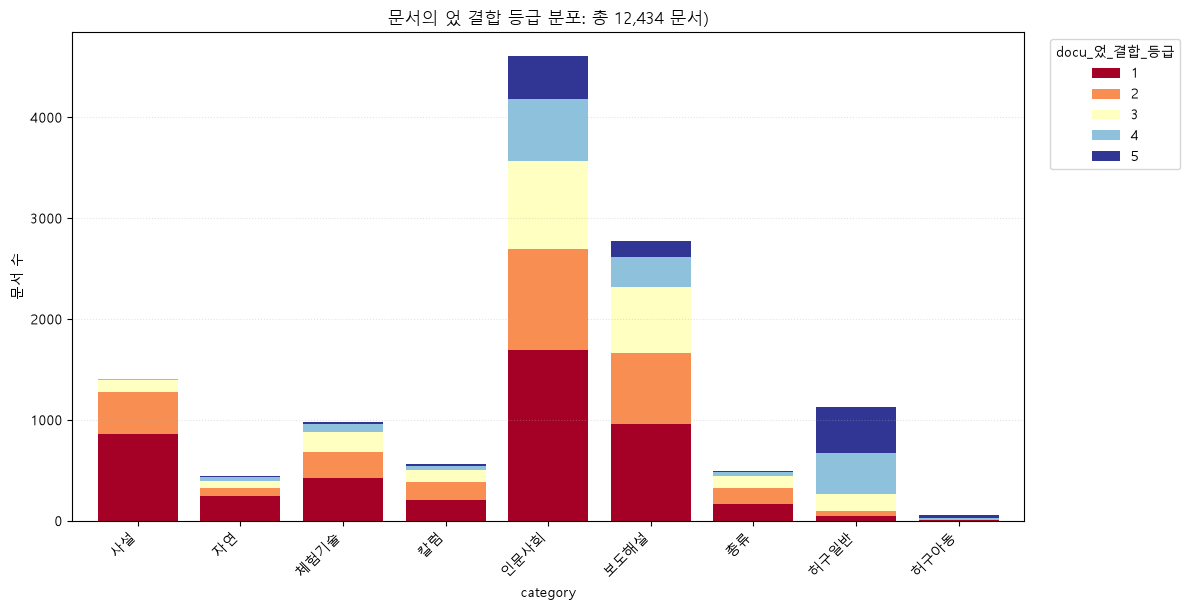

그래프 저장: C:\Users\whyeon\Projects\__data\document_histogram\었결합등급_히스토그램_total_percent_vertical_20260708_10-33-37.png


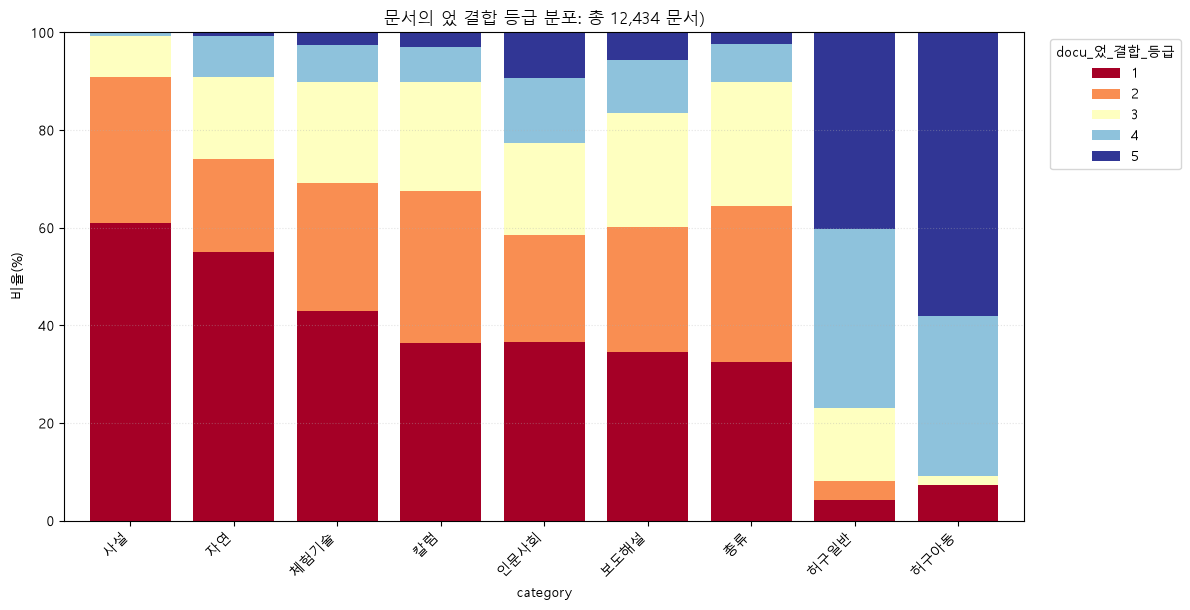

In [ ]:
categories = get_group_order(df_hist, CATEGORY_COL, CATEGORY_ORDER_MODE, CUSTOM_CATEGORY_ORDER)
saved_figures = []

if SAVE_FIGURE:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H-%M-%S")

value_modes = [VALUE_MODE]
if DRAW_PERCENT_HISTOGRAM and "percent" not in value_modes:
    value_modes.append("percent")

for category in categories:
    for value_mode in value_modes:
        table = make_category_table(df_hist, category, value_mode)
        if table.empty:
            print(f"건너뜀: {category} - 표시할 문서 유형이 없습니다.")
            continue

        if HISTOGRAM_ORIENTATION == "horizontal":
            plot_kind = "barh"
            figsize = (FIG_WIDTH, max(MIN_FIG_HEIGHT, BAR_HEIGHT * len(table) + 1.8))
        else:
            plot_kind = "bar"
            figsize = (max(FIG_WIDTH, 0.65 * len(table) + 4), MIN_FIG_HEIGHT + 1.2)

        ax = table.plot(
            kind=plot_kind,
            stacked=STACKED,
            figsize=figsize,
            width=0.78,
            colormap="RdYlBu",#"tab20","magma", 'viridis', 'plasma', 'inferno', 'magma', 'cividis'
                            #Diverging colormap: ['PiYG', 'PRGn', 'BrBG', 'PuOr', 'RdGy', 'RdBu', 'RdYlBu', 'RdYlGn', 'Spectral', 'coolwarm', 'bwr', 'seismic']
        )

        axis_label = "문서 수" if value_mode == "count" else "비율(%)"
        title_suffix = "문서 수" if value_mode == "count" else "비율"
        if HISTOGRAM_ORIENTATION == "horizontal":
            ax.set_yticklabels([shorten_label(label.get_text()) for label in ax.get_yticklabels()])
            ax.set_xlabel(axis_label)
            ax.set_ylabel(TYPE_COL)
            ax.grid(axis="x", linestyle=":", alpha=0.35)
            if value_mode == "percent":
                ax.set_xlim(0, 100)
        else:
            ax.set_xticklabels([shorten_label(label.get_text()) for label in ax.get_xticklabels()], rotation=45, ha="right")
            ax.set_xlabel(TYPE_COL)
            ax.set_ylabel(axis_label)
            ax.grid(axis="y", linestyle=":", alpha=0.35)
            if value_mode == "percent":
                ax.set_ylim(0, 100)

        ax.set_title(f"문서의 었 결합 등급 분포: 총 {len(df_hist):,} 문서")
        ax.legend(title=GRADE_COL, bbox_to_anchor=(1.02, 1), loc="upper left")

        fig = ax.get_figure()
        fig.tight_layout()

        if SAVE_FIGURE:
            saved_figure = FIGURE_DIR / f"었결합등급_히스토그램_{safe_filename(category)}_{value_mode}_{HISTOGRAM_ORIENTATION}_{timestamp}.png"
            fig.savefig(saved_figure, dpi=FIGURE_DPI, bbox_inches="tight")
            saved_figures.append(saved_figure)
            print(f"그래프 저장: {saved_figure}")

        plt.show()


In [47]:
if SAVE_FIGURE:
    summary_rows = []
    for category in categories:
        for value_mode in value_modes:
            table = make_category_table(df_hist, category, value_mode)
            if table.empty:
                continue
            long_table = table.reset_index().melt(
                id_vars=TYPE_COL,
                var_name=GRADE_COL,
                value_name="문서수" if value_mode == "count" else "비율",
            )
            long_table.insert(0, "표시방식", value_mode)
            long_table.insert(0, CATEGORY_COL, category)
            summary_rows.append(long_table)

    if summary_rows:
        summary = pd.concat(summary_rows, ignore_index=True)
        summary_path = FIGURE_DIR / f"문서_군집_히스토그램_요약_{HISTOGRAM_ORIENTATION}_{timestamp}.csv"
        summary.to_csv(summary_path, index=False, encoding="utf-8-sig")
        print(f"요약 저장: {summary_path}")


요약 저장: C:\Users\whyeon\Projects\__data\document_histogram\문서_군집_히스토그램_요약_vertical_20260708_01-06-37.csv
